In [1]:
import qiskit
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import UnitaryGate, Reset
import matplotlib.pyplot as plt
import math
import numpy as np
from qiskit.visualization import plot_histogram, plot_state_city
from qiskit.quantum_info import Statevector


from qiskit.visualization import array_to_latex
from IPython.display import display

a=0.01*math.pi
n=3
m=2**n
circ=QuantumCircuit(n,n)
for i in range(n-1):
    circ.h(i+1)
U=np.zeros((m,m), dtype=np.complex128)
for i in range(0,m,2):
    U[i][i]=np.cos(i*a)
    U[i][i+1]=np.sin(i*a)
    U[i+1][i]=-np.sin(i*a)
    U[i+1][i+1]=np.cos(i*a)

display(array_to_latex(U.data, prefix="U = "))
print(U)
gate=UnitaryGate(U)
circ.append(gate,[0,1,2])

<IPython.core.display.Latex object>

[[ 1.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [-0.        +0.j  1.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.99802673+0.j  0.06279052+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j -0.06279052+0.j  0.99802673+0.j
   0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.9921147 +0.j  0.12533323+0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
  -0.12533323+0.j  0.9921147 +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   0.        +0.j  0.        +0.j  0.98228725+0.j  0.18738131+0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j  0.        +0.j
   

In [2]:
state=Statevector(circ) #norm = 1
display(array_to_latex(state.data, prefix="|\\psi\\rangle = "))
print(state)

<IPython.core.display.Latex object>

Statevector([ 0.5       +0.j,  0.        +0.j,  0.49901336+0.j,
             -0.03139526+0.j,  0.49605735+0.j, -0.06266662+0.j,
              0.49114363+0.j, -0.09369066+0.j],
            dims=(2, 2, 2))


In [3]:
print(circ.draw())

          ┌──────────┐
q_0: ─────┤0         ├
     ┌───┐│          │
q_1: ┤ H ├┤1 Unitary ├
     ├───┤│          │
q_2: ┤ H ├┤2         ├
     └───┘└──────────┘
c: 3/═════════════════
                      


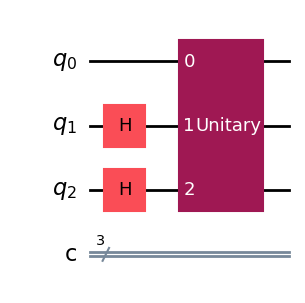

In [4]:
circ.draw("mpl")

In [5]:
y=np.zeros(4)
for i in range(4):
    y[i]=state[2*i]

/tmp/ipykernel_366/3552740058.py:3: ComplexWarning: Casting complex values to real discards the imaginary part
  y[i]=state[2*i]


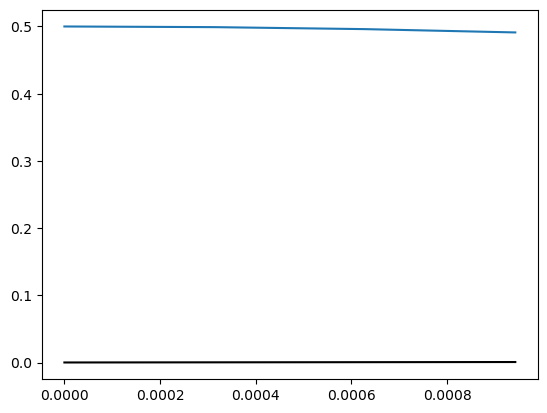

In [6]:
s=np.zeros(4)
for i in range(4):
 s[i]=0.0001*math.pi*i
plt.plot(s,y)
plt.plot(s,0.707*np.sin(s+0.0001*math.pi), 'k')
plt.show()

In [7]:
circ.reset(0)
circ_measured = circ.measure_all(inplace=False)


from qiskit.primitives import StatevectorSampler
sampler=StatevectorSampler()
job=sampler.run([circ_measured],shots=1000)
result= job.result()

DataBin(c=BitArray(<shape=(), num_shots=1000, num_bits=3>), meas=BitArray(<shape=(), num_shots=1000, num_bits=3>))
{'010': 241, '100': 223, '110': 259, '000': 277}


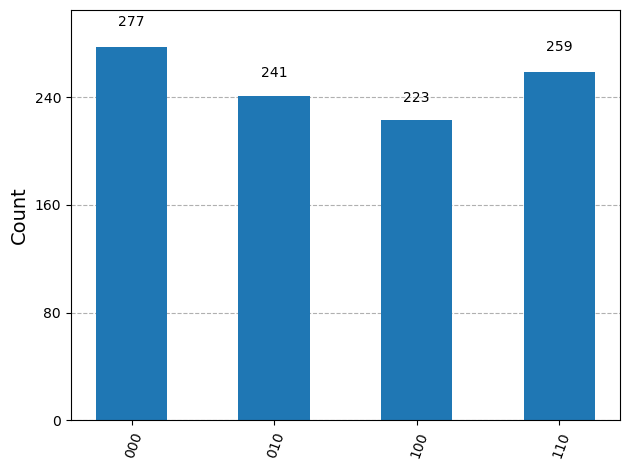

In [8]:
result = job.result()

print(result[0].data)

circ_measured = circ.measure_all(inplace=False)
counts = result[0].data.meas.get_counts()
print(counts)

plot_histogram(counts)

Raw shot-level data array: <memory at 0x7fb075efc1e0>


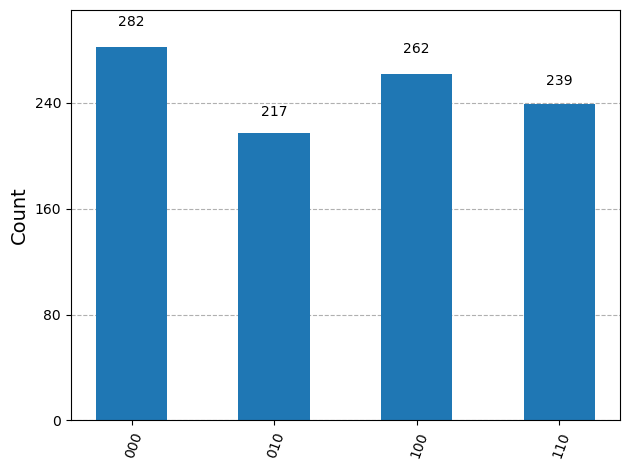

In [9]:
from qiskit.primitives import StatevectorSampler
sampler=StatevectorSampler()
job=sampler.run([circ_measured],shots=1000)
result= job.result()


shot_data_array = result[0].data.c.array
print(f"Raw shot-level data array: {shot_data_array.data}")


# You can still get a Counts dictionary from this data if needed
#counts_from_array = result[0].data.c0.get_counts()
#print(f"Counts from array data: {counts_from_array}")
counts_ideal=result[0].data["meas"].get_counts()
plot_histogram(counts_ideal)

In [10]:
outcomes_array = np.array(list(counts_ideal.keys()))

print(f"Outcomes array: {outcomes_array}")

Outcomes array: ['010' '110' '000' '100']


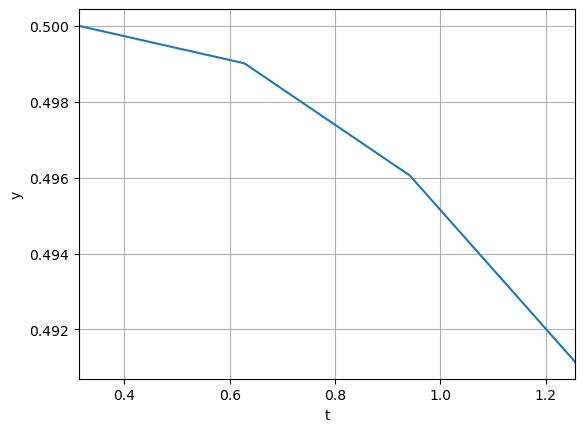

In [11]:
t = np.arange(0.314, 1.2566, 0.314)
plt.plot(t,y)
plt.margins(x=0)
plt.grid()
plt.xlabel("t")
plt.ylabel("y")
plt.show()